In [66]:
import seaborn as sns
import polars as pl
import matplotlib.pyplot as plt

PLOT_DIR = "../docs/presentation/images/plots/"
DATA_DIR = "./data/"

In [67]:
train_loss = pl.read_csv(DATA_DIR + "train_loss" + ".csv")
val_iou = pl.read_csv(DATA_DIR + "val_iou" + ".csv")
val_loss = pl.read_csv(DATA_DIR + "val_loss" + ".csv")
val_psnr = pl.read_csv(DATA_DIR + "val_psnr" + ".csv")
val_rec_mask_mse = pl.read_csv(DATA_DIR + "val_rec_mask_mse" + ".csv")
val_rec_rgb_mse = pl.read_csv(DATA_DIR + "val_rec_rgb_mse" + ".csv")

In [68]:
def splitting(df: pl.DataFrame, col:str, type: str, grid: int, init: str):
    return df.select("step", col).with_columns(
        pl.lit(type).alias("type"), 
        pl.lit(grid).alias("grid"),
        pl.lit(init).alias("init"),
        pl.lit(col).alias("id")
    ).rename({col: "value"})

def renaming(df: pl.DataFrame, suffix: str):
    mapping = {
        f"08-02_18-31-55_ShapeNet_NeMo_Rec_local - {suffix}": "dmtet_16_sphere",
        f"08-02_17-19-48_ShapeNet_NeMo_Rec_local - {suffix}": "flex_32_random",
        f"08-02_16-08-21_ShapeNet_NeMo_Rec_local - {suffix}": "flex_16_random",
        f"08-01_16-48-36_ShapeNet_NeMo_Rec_local - {suffix}": "dmtet_32_random",
        f"08-01_16-23-41_ShapeNet_NeMo_Rec_local - {suffix}": "dmtet_32_sphere",
        f"08-01_15-07-07_ShapeNet_NeMo_Rec_local - {suffix}": "flex_32_sphere",
        f"08-01_14-45-02_ShapeNet_NeMo_Rec_local - {suffix}": "dmtet_16_random",
        f"08-01_13-40-44_ShapeNet_NeMo_Rec_local - {suffix}": "flex_16_sphere",
        "Step": "step"
    }
    df = df.rename(mapping=mapping)

    cols = [
        "step",
        "dmtet_16_sphere",
        "flex_32_random",
        "flex_16_random",
        "dmtet_32_random",
        "dmtet_32_sphere",
        "flex_32_sphere",
        "dmtet_16_random",
        "flex_16_sphere",
    ]

    map = {
        i : {
            k[0]: k[1]
            for k in zip(["type", "grid", "init"], i.split("_"))
        }
        for i in cols[1:]
    }
    

    df = df.select(*cols)

    dfs = []
    for col in cols[1:]:
        vals = map[col]
        dfs.append(splitting(df, col, vals["type"], int(vals["grid"]), vals["init"]))

    df = pl.concat(dfs)
    return df

In [69]:
train_loss = renaming(train_loss, "train/loss")
val_iou = renaming(val_iou, "val/shapenet/iou")
val_loss = renaming(val_loss, "val/shapenet/loss")
val_psnr = renaming(val_psnr, "val/shapenet/psnr")
val_rec_mask_mse = renaming(val_rec_mask_mse, "val/shapenet/rec_mask_mse")
val_rec_rgb_mse = renaming(val_rec_rgb_mse, "val/shapenet/rec_rgb_mse")

In [70]:
sns.set_theme(style="darkgrid", palette="Spectral")
sns.set_context("paper")

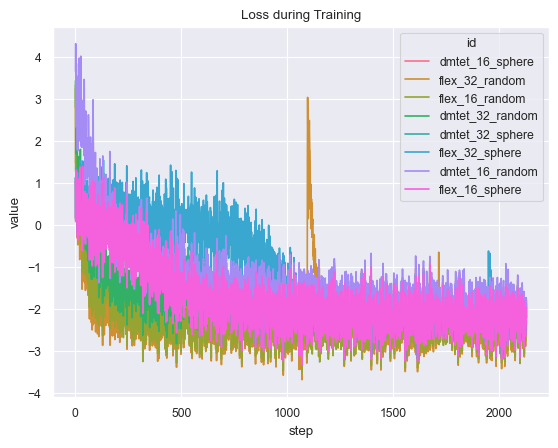

In [71]:
sns.lineplot(train_loss, x="step", y="value", hue="id")
plt.title("Loss during Training")
plt.savefig(PLOT_DIR + "train_loss" + ".png")

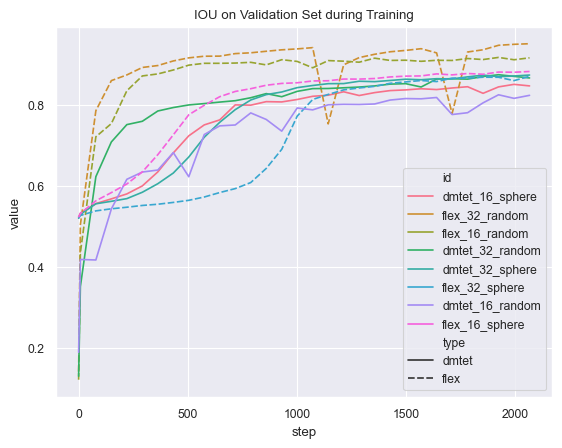

In [72]:
sns.lineplot(val_iou, x="step", y="value", hue="id", style="type")
plt.title("IOU on Validation Set during Training")
plt.savefig(PLOT_DIR + "val_iou" + ".png")

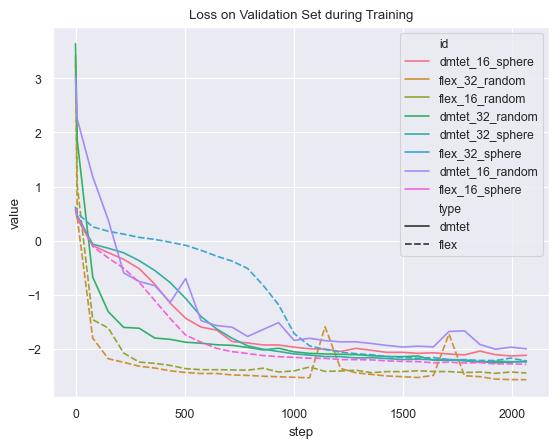

In [73]:
sns.lineplot(val_loss, x="step", y="value", hue="id", style="type")
plt.title("Loss on Validation Set during Training")
plt.savefig(PLOT_DIR + "val_loss" + ".png")

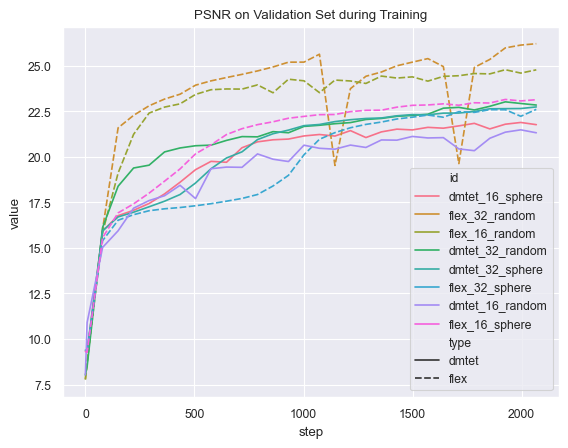

In [74]:
sns.lineplot(val_psnr, x="step", y="value", hue="id", style="type")
plt.title("PSNR on Validation Set during Training")
plt.savefig(PLOT_DIR + "val_psnr" + ".png")

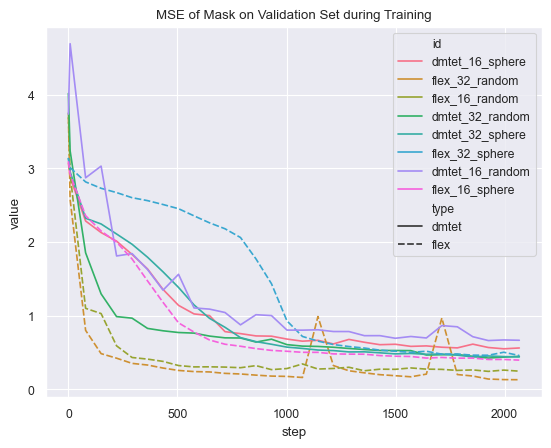

In [75]:
sns.lineplot(val_rec_mask_mse, x="step", y="value", hue="id", style="type")
plt.title("MSE of Mask on Validation Set during Training")
plt.savefig(PLOT_DIR + "val_rec_mask_mse" + ".png")

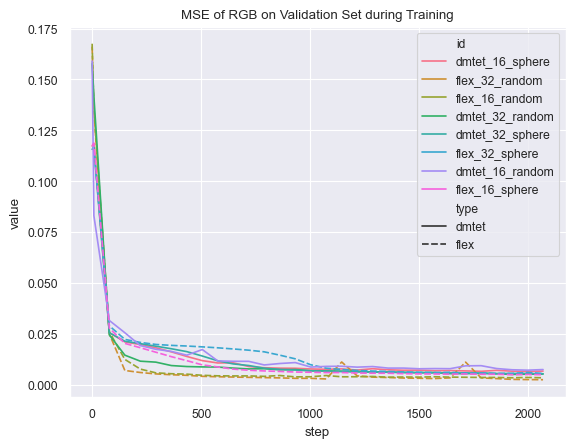

In [76]:
sns.lineplot(val_rec_rgb_mse, x="step", y="value", hue="id", style="type")
plt.title("MSE of RGB on Validation Set during Training")
plt.savefig(PLOT_DIR + "val_rec_rgb_mse" + ".png")